# Plot regional mortality due to ozone exposure as a box plot

Using CESM2, SSP2-4.5 ensemble member 1 as an example

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from utils.utils import autosize_figure, get_scenario_config
import config
from utils.utils import require_dir
import pathlib

In [2]:
def process_mortality_per_100k(model, scenario, years, ens_num, n_samples):
    # === Path config ===
    DIR = require_dir(pathlib.Path(config.WORK_ROOT) / model / "mortality" / "ozone")
    MASK_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "region")
    POP_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "SSP_pop" / "SSP2")

    # === Load data ===
    mask_file = "GBD_Region_Masks_0.10.nc"
    mask_path = os.path.join(MASK_DIR, mask_file)
    mask = xr.open_dataarray(mask_path)

    # Regional population
    pop_file = "ssp2_region_level_2000-2100.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    population = xr.open_dataarray(pop_path)
    pop = population.reindex_like(mask, method="nearest", tolerance=1e-9)

    dates = f"{years.start}-{years.stop - 1}"

    file = f"Regional_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
    path = os.path.join(DIR, file)
    da = xr.open_dataarray(path)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last.year[0].item()
    end_time = da_last.year[-1].item()

    # Calculate temporal mean
    da_mean = da_last.mean("year")

    # Calculate population mean
    years = slice(start_time, end_time)
    av_pop = pop.sel(year=years).mean("year")

    # Calculate mortality per 100,000
    da_per_100k = (da_mean/av_pop)*100000
    return da_per_100k, start_time, end_time

In [29]:
def plot_regional_mortality(da_mean, model, scenario, ens_num, first_year, last_year, SAVE_DIR):
    # Sort regions by mean value
    region_means = da_mean.mean(dim="samples")
    sorted_regions = region_means.sortby(region_means).region.values

    # Compute summary stats per region: mean, median, and 95% CI (2.5/97.5 percentiles)
    means = da_mean.mean(dim="samples").sel(region=sorted_regions).values
    medians = da_mean.median(dim="samples").sel(region=sorted_regions).values
    lower = da_mean.quantile(0.025, dim="samples").sel(region=sorted_regions).values
    upper = da_mean.quantile(0.975, dim="samples").sel(region=sorted_regions).values

    # Asymmetric error bars from the mean out to the CI bounds
    lower_err = means - lower
    upper_err = upper - means

    fcolor = "#FEA571"
    plt.rcParams.update({'font.size': 16})

    y_pos = np.arange(1, len(sorted_regions) + 1)

    # Plot
    plt.figure(figsize=autosize_figure(1, 1, yscale_factor=2))

    # 95% CI whiskers
    plt.errorbar(means, y_pos, xerr=[lower_err, upper_err],
                 fmt="none", ecolor="gray", elinewidth=1,
                 capsize=4, capthick=1, zorder=1)

    # Mean markers
    plt.scatter(means, y_pos, color=fcolor, edgecolor="gray",
                s=200, zorder=3, label="Mean")

    # Median markers
    plt.scatter(medians, y_pos, facecolor="white", edgecolor="gray",
                marker="D", s=50, zorder=3, label="Median")

    plt.yticks(y_pos, sorted_regions)
    plt.xlabel("COPD mortality per 100,000 (year$^{-1}$)")
    plt.title(f"{model} {scenario} ensemble {ens_num}\n {first_year}-{last_year}")
    plt.grid(axis="y", linestyle=':', alpha=0.5)
    plt.grid(axis='x', linestyle='--', alpha=0.8)
    plt.legend(frameon=False, loc="lower right")

    # Symmetric log scale
    plt.xscale('symlog', linthresh=1)

    # Use ScalarFormatter to show tick labels as real numbers
    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    plt.gca().xaxis.set_major_formatter(formatter)

    out_file = f"Mortality_per_100k_ozone_region_meanCI_{model}_{scenario}_{first_year}-{last_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    return

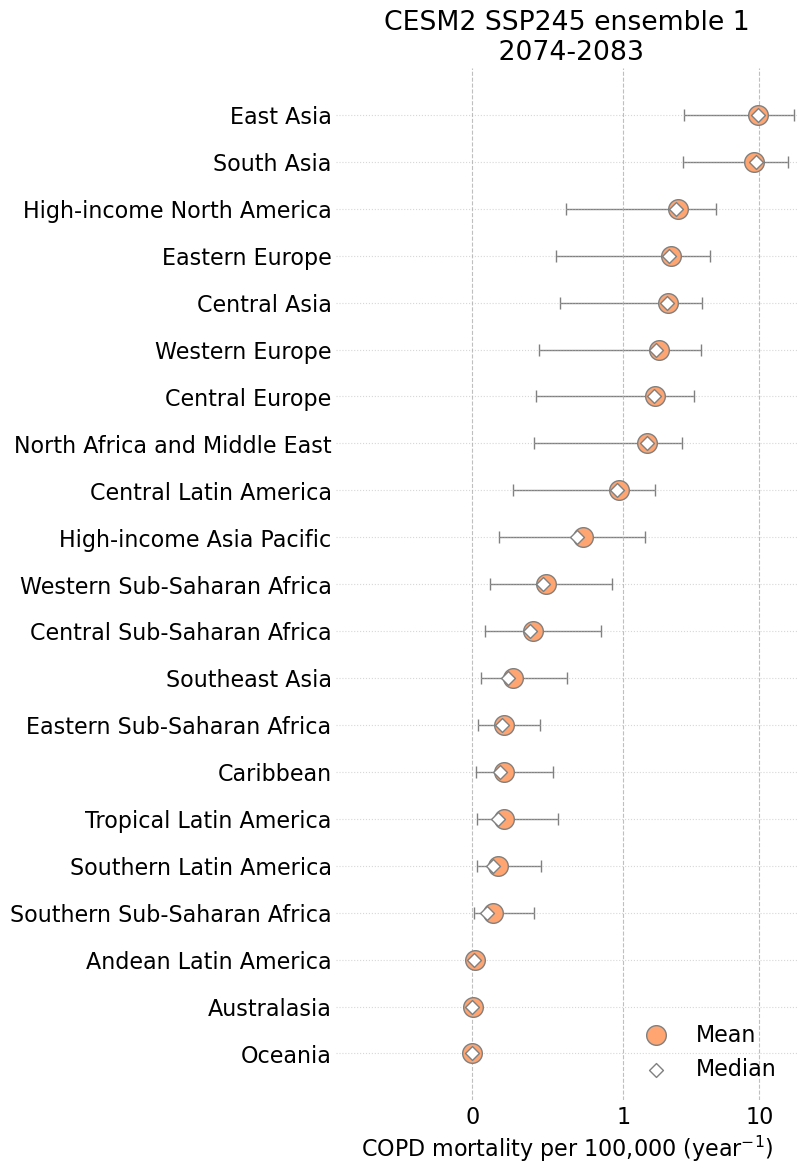

In [30]:
# === Path Config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "example_workflow")

model = "CESM2"
scenario = "SSP245"
ensemble_number = 1

configs = get_scenario_config(model, scenario)
years = configs["years"]

n_samples = 300

# Final 10 years per 100k
da_mean, first_year, last_year = process_mortality_per_100k(model, scenario, years, ensemble_number, n_samples)

plot_regional_mortality(da_mean, model, scenario, ensemble_number, first_year, last_year, SAVE_DIR)